## 균등, 주사위 분포
Colab. 보여주자. 확인하자.

In [1]:
# _lln_00.py
# law of large numbers, 오차의 크기

import os
import numpy as np                          # numpy 라이브러리 전체.
import pandas as pd                         # pandas 라이브러리 전체, 시계열(기본) 여기 있네.
import scipy as sci
from scipy import stats, optimize, linalg   # scipy 라이브러리 하부 모듈. 필요한 통계 모듈만.
import statsmodels.api as sm                # 방대한 모델이라 개발자들이 많이 쓰는 모델 묶음.
from statsmodels.tsa import stattools       # time series analysis
from statsmodels.tsa.arima.model import ARIMA # 이거 가능하다 이거지. 이거 대문자네. 꼭. 소문자 못읽어.
import matplotlib.pyplot as plt


### 파라메타 설정

In [2]:
# 필요한 파라메터 설정
n_smpl = 100

# 임의변수 생성, 균등분포, 정규분포.
seed = 135678942   # 시드

# 균등분포 시작, 끝, 분산 = (b-a)^2/12 =약 225.33, 표편 약 15.01
x_beg = 74
x_end = 126

# 주사위 분포
x_die = np.array([1,2,3,4,5,6])

# 정규분포라면 이렇게.
mu = 100
sig = 15


### 균등분포
 $ X_i \sim U(a, b) $이면(균등분포),  
$$ E(X_i) = { a + b \over 2} , \quad  Var (X_i) = {(b-a )^2 \over 12} $$

$ a=74, b= 126 $일 때, $ \mu=100,\ \sigma^2 =225.3,\ \sigma = 15.01 $.

for large $ n $,
$$ \bar X \approx N( \mu, SE^2) , \quad SE = {\sigma \over \sqrt n } $$.

$ \bar X $의 평균 100, 표준오차 $ 15.01 \over \sqrt n $.

$ n=1000 \to SE =0.474 $,  $ n=10000 \to SE = 0.15 $, ...  

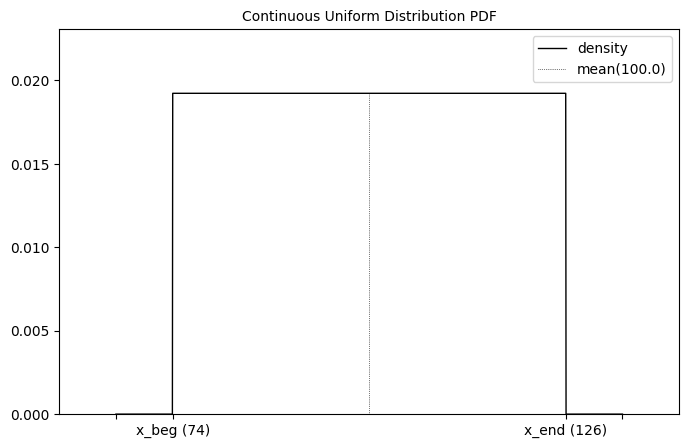

In [3]:
# 균등분포 밀도
# 1. 구간 및 기본 파라미터 설정
# x_beg = 10
# x_end = 20

# 균등분포 이론상 평균, 표준편차 (sig_x) 계산
meanx = (x_beg + x_end)/2
sig_x = ((x_end - x_beg)**2 / 12)**0.5

# 2. X축 데이터 배열 생성
# 그래프 양옆의 0인 구간을 명확히 보여주기 위해 시작점 좌우로 표준편차의 절반만큼 넓게 잡았습니다.
x = np.linspace(x_beg - sig_x/2, x_end + sig_x/2, 1500)

# 3. 넘파이 배열 연산용으로 조건문 수정 (에러 해결 핵심)
# x_beg(10) 이상, x_end(20) 미만인 위치만 높이를 1/(20-10) = 0.1로 지정하고 나머지는 0으로 채움
f_x = np.where((x >= x_beg) & (x < x_end), 1 / (x_end - x_beg), 0)

f_max = max(f_x)
y_max = f_max*1.2
x_ref = meanx                             # 분포에서 살펴볼 지점, 평균.
x_look = [x_ref, x_ref ]                  # 히스토그램에 표시할 x 좌표
y_look = [0, f_max] # 히스토그램에 표시할 y 좌표

# 4. 시각화 그래프 작성
plt.figure(figsize=(16/2, 10/2)) # 화면 비율 약 16:9 설정

# 확률밀도함수 곡선 그리기
plt.plot(x, f_x, color='black', linewidth=1, label='density')
plt.plot(x_look, y_look, color='black', linewidth=0.51, linestyle='dotted', label=f'mean({x_ref})')

# 사각형 내부 은은하게 색 채우기
#plt.fill_between(x, f_x, color='royalblue', alpha=0.1)

# 축 및 레이블 설정
plt.title('Continuous Uniform Distribution PDF', fontsize=10 ) # fontweight='bold', pad=15)
#plt.xlabel('x', fontsize=12)
#plt.ylabel('f(x) : Density', fontsize=12)

# X축 눈금을 시작점과 끝점으로 명확하게 표시
plt.xticks([x_beg - sig_x/2, x_beg, x_end, x_end + sig_x/2],
           [ ' ', f'x_beg ({x_beg})', f'x_end ({x_end})', '' ])
plt.ylim(0, y_max )         # Y축 여백 설정
plt.xlim(x_beg - sig_x, x_end + sig_x)
plt.legend()
plt.show()


### 주사위 실험 분포
 $ X_i =i \ with\ p={1 \over 6}, \ i=1,\cdots, 6 $. (주사위 실험),  
$$ E(X_i) = 3.5 , \quad  Var (X_i) = {35 \over 12}\approx 2.92 $$

$ \mu= 3.5,\ \sigma^2 =2.92,\ \sigma = 1.71 $.

for large $ n $,
$$ \bar X \approx N( \mu, SE^2) , \quad SE = {\sigma \over \sqrt n } $$.

$ \bar X $의 평균 3.5, 표준오차 $ 1.71 \over \sqrt n $.

$ n=1000 \to SE =0.054 $,  $ n=10000 \to SE = 0.017 $, ...  

평균 3.5, 표준편차 1.707825127659933


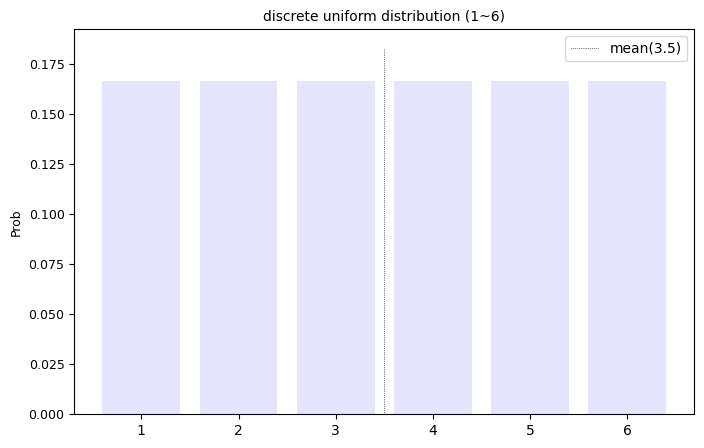

In [55]:
# 주사위 분포 밀도->확률
# 1. 구간 및 기본 파라미터 설정
x_s = 1          # 정수 간격, 이런 거 일반화 아이디어.
x_a = 1
x_b = 6 + x_s

x = np.arange( x_a, x_b, x_s)   # a, b 까지, x_s 단위로.
p = 1/len(x)
#print(x)

avg_x = x.mean()
sig_x = x.std(ddof=0)
print(f"평균 {avg_x}, 표준편차 {sig_x}")

y_max = p*1.1                             # 분포에서 표시할 최대 높이.
x_ref = avg_x                             # 분포에서 살펴볼 지점, 평균.
x_look = [x_ref, x_ref ]                  # 히스토그램에 표시할 x 좌표
y_look = [0, y_max]                       # 히스토그램에 표시할 y 좌표

# # 4. 시각화 그래프 작성
plt.figure(figsize=(16/2, 10/2)) # 화면 비율 약 16:9 설정

# 확률 매스 바 그리기
plt.bar(x, p, color='blue', linewidth=1, alpha=0.1 )
plt.plot(x_look, y_look, color='black', linewidth=0.51, linestyle='dotted', label=f'mean({x_ref})')

# # 사각형 내부 은은하게 색 채우기
# #plt.fill_between(x, f_x, color='royalblue', alpha=0.1)

# # 축 및 레이블 설정
plt.title(f'discrete uniform distribution ({x_a}~{x_b-x_s })', fontsize=10 ) # fontweight='bold', pad=15)
#plt.xlabel('prob', fontsize=9)
plt.ylabel('Prob', fontsize=9)
plt.yticks(fontsize=9)
plt.xticks( x )  # 이게 리스트나 어래이 되는 모양이네.
#plt.xticks([x_a, x_b-1], [ f'a ({x_a})', f'b ({x_b-1})'])

plt.legend()
plt.show()


(50/4)**0.5

In [51]:
v=(50/3)**0.5
v

4.08248290463863